# Predict results

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# import torch
# import numpy as np
# from torchvision.models import resnet18
# from models.CombinedRes18 import MLP
# from models.CombinedRes18 import CombinedModel
# from utils import device, show_dl, plot_dl
# from poutyne.framework import Model
# from Project import Project
# import torch.optim as optim
# from torchsummary import summary
# from data import get_combined_dataloaders


# project = Project()
# model_saved_path = str(project.checkpoint_dir /
#                             "19 July combinedCV_final.pt")

#  # create a fresh instance of resnet18 for each fold
# resnet18 = resnet18(weights="IMAGENET1K_V1")
# mlp = MLP(input_size=3, hidden_size=32, output_size=16) 
# cnn = CombinedModel(resnet18, mlp, 2).to(device)
# cnn.load_state_dict(torch.load(model_saved_path))


# from data.transformation import train_transform, val_transform
# from torch.utils.data import DataLoader

# # replacing the ImageFolder with our custom ImageFolderWithPaths
# #from torchvision.datasets.folder import ImageFolder
# from data import ImageFolderWithPaths

# params = {
#         'lr': 1e-4,
#         'batch_size': 32,
#         'epochs': 100,
#         'model': 'CRnet18-FTmod'
#     }
# # test_dir = "./dataset/visu/" 
# train_dl, val_dl, test_dl = get_combined_dataloaders(
#         project.data_dir / "combined_dataset/train",
#         project.data_dir / "combined_dataset/val",
#         val_transform=val_transform,
#         train_transform=train_transform,
#         batch_size=params['batch_size'],
#         pin_memory=False,
#         num_workers=8,
#     )

In [ ]:
# print(cnn)

In [ ]:
# # defining hook to access output from intermidiate layer
# def get_features(name):
#     def hook(model, input, output):
#         features[name] = output.detach()
#     return hook

# # registerning the hook. different layer can be accessed by changing
# # fc[3] parameter. for details 
# # https://kozodoi.me/python/deep%20learning/pytorch/tutorial/2021/05/27/extracting-features.html

# # print(model)
# cnn.combined[3].register_forward_hook(get_features('feats'))
# # cnn.conv1.register_forward_hook(get_features('feats'))


# y_pred = []
# y_true = []
# FEATS = [] # extracted feats will be saved here
# # placeholder for batch features
# features = {}
# targets = []

# with torch.no_grad():
#     for batch in test_dl:
#         # unpack the batch
#         (images, csvs), targets = batch
#         # move them to the device
#         images, csvs, targets = images.to(device), csvs.to(device), targets.to(device)
        
#         # calculate outputs by running images, csvs through the model
#         outputs = cnn(images, csvs)
#         # the class with the highest energy is what we choose as prediction
#         _, preds = torch.max(outputs, 1)
        
#         y_true.extend(targets.cpu().numpy())
#         y_pred.extend(preds.cpu().numpy())
#         FEATS.extend((features['feats'].cpu().numpy())) # Save feature
            
#     # for image, target in test_dl:
#     #     image, target = image.to(device), target.to(device)
#     #     outputs = cnn(image)
#     #     output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
#     #     y_pred.extend(output) # Save Prediction
#     #     target = target.data.cpu().numpy()
        
#     #     targets.extend(target) # Save target
#     #     FEATS.extend((features['feats'].cpu().numpy())) # Save feature
        
# FEATS = np.array(FEATS)
# print(f' Feature extracted with shape: (m, C, H, W) = {np.array(FEATS).shape}')

In [ ]:
# square = 23
# ix = 1
# graph_loc = './Results/feature_maps/'

# import matplotlib.pyplot as plt
# import seaborn_image as isns

# ax, fig = plt.subplots(square, square, figsize=(20, 20))

# for _ in range(square):
#  for _ in range(square):
#     # specify subplot and turn of axis
#     ax = plt.subplot(square, square, ix)
#     ax.set_xticks([])
#     ax.set_yticks([])
    
#     try:
#         # plot filter channel in grayscale
#         plt.imshow(FEATS[0, ix-1, :, :], cmap='magma')
#     except:
#         pass

#     ix += 1
    
# # save the figure
# plt.savefig(graph_loc + "L4_1_conv2.svg", format='svg', dpi=300, bbox_inches='tight')

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# square = 8
# ix = 1

# fig, axs = plt.subplots(square, square, figsize=(20, 20))

# for i in range(square):
#     for j in range(square):
#         ax = axs[i, j]
#         ax.set_xticks([])
#         ax.set_yticks([])
#         sns.heatmap(FEATS[0, ix-1, :, :], cmap='rocket', ax=ax, cbar=False)

#         ix += 1

# plt.show()


# TSNE plot of features

In [ ]:
import torch
import numpy as np
from torchvision.models import resnet18
from models.CombinedRes18 import MLP
from models.CombinedRes18 import CombinedModel
from utils import device, show_dl, plot_dl
from poutyne.framework import Model
from Project import Project
import torch.optim as optim
from torchsummary import summary
from data import get_combined_dataloaders


project = Project()
model_saved_path = str(project.checkpoint_dir /
                            "19 July combinedCV_final.pt")

 # create a fresh instance of resnet18 for each fold
resnet18 = resnet18(weights="IMAGENET1K_V1")
mlp = MLP(input_size=3, hidden_size=32, output_size=16) 
cnn = CombinedModel(resnet18, mlp, 2).to(device)
cnn.load_state_dict(torch.load(model_saved_path))


from data.transformation import train_transform, val_transform
from torch.utils.data import DataLoader

# replacing the ImageFolder with our custom ImageFolderWithPaths
#from torchvision.datasets.folder import ImageFolder
from data import ImageFolderWithPaths

params = {
        'lr': 1e-4,
        'batch_size': 32,
        'epochs': 100,
        'model': 'CRnet18-FTmod'
    }
# test_dir = "./dataset/visu/" 

dataset1, dataset2, val_dl = get_combined_dataloaders(
        project.data_dir / "combined_dataset/train",
        project.data_dir / "combined_dataset/val",
        val_transform=val_transform,
        train_transform=train_transform,
        batch_size=params['batch_size'],
        pin_memory=False,
        num_workers=8,
    )

from torch.utils.data import ConcatDataset
# Assuming `dataset1` and `dataset2` are your datasets
train_dl = ConcatDataset([dataset1, dataset2])

In [ ]:
# defining hook to access output from intermidiate layer
def get_features(name):
    def hook(model, input, output):
        features[name] = output.detach()
    return hook

# registerning the hook. different layer can be accessed by changing
# fc[3] parameter. for details 
# https://kozodoi.me/python/deep%20learning/pytorch/tutorial/2021/05/27/extracting-features.html

# print(model)
cnn.combined[3].register_forward_hook(get_features('feats'))
# cnn.conv1.register_forward_hook(get_features('feats'))


y_pred = []
y_true = []
FEATS = [] # extracted feats will be saved here
# placeholder for batch features
features = {}
targets = []
csvs_arr = []

with torch.no_grad():
    for batch in val_dl:
        # unpack the batch
        (images, csvs), targets = batch
        # move them to the device
        images, csvs, targets = images.to(device), csvs.to(device), targets.to(device)
        
        # calculate outputs by running images, csvs through the model
        outputs = cnn(images, csvs)
        # the class with the highest energy is what we choose as prediction
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        FEATS.extend((features['feats'].cpu().numpy())) # Save feature
        csvs_arr.extend(csvs.cpu().numpy())
           
    # for image, target in test_dl:
    #     image, target = image.to(device), target.to(device)
    #     outputs = cnn(image)
    #     output = (torch.max(outputs, 1)[1]).data.cpu().numpy()
    #     y_pred.extend(output) # Save Prediction
    #     target = target.data.cpu().numpy()
        
    #     targets.extend(target) # Save target
    #     FEATS.extend((features['feats'].cpu().numpy())) # Save feature
    
y_pred, y_true = np.array(y_pred).reshape(-1,1), np.array(y_true).reshape(-1,1)
FEATS = np.array(FEATS)
print(f' Feature extracted with shape: (m, C, H, W) = {np.array(FEATS).shape}')

In [ ]:
from sklearn.manifold import TSNE

# Load the dataset and perform t-SNE embedding
tsne_proj = TSNE(n_components=2, perplexity= 100,n_iter=50000).fit_transform(FEATS.reshape(FEATS.shape[0], -1))

### save TSNE fit to csv

In [ ]:
import pandas as pd
df = pd.DataFrame(np.concatenate((csvs_arr, FEATS, tsne_proj, y_pred, y_true), axis=1))
df.to_csv('./Results/Combined/feats.csv', index=False)

### load TSNE fit from csv

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('./Results/Combined/feats.csv')

# FEATS = last two colimns
tsne_proj = df.iloc[:, -4:-2].values
y_pred, y_true = df.iloc[:, -2].values, df.iloc[:, -1].values
print(f' TSNE shape: (m, n) = {np.array(tsne_proj).shape}')

In [ ]:
print(f' y_pred shape: (m, n) = {y_true.shape}')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import numpy as np

colors2 = ['#1f77b4', '#ff7f0e'] # matplotlib default color cycle
font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50


fig, ax = plt.subplots(figsize=(20,10), dpi= 300)

# Rename the ticks
plot_labels = ['WBC', 'HCT-116']  

for lab in range(2):
    indices = np.array(y_pred)==lab

    sc = ax.scatter(tsne_proj[indices,0],tsne_proj[indices,1], s=150, color=colors2[lab],  label = plot_labels[lab], alpha=0.7)


# for lab in range(2):
#     indices = np.array(y_pred)==lab
#     correct_predictions = np.array(y_pred)==np.array(y_true)
#     incorrect_predictions = np.array(y_pred)!=np.array(y_true)
    
#     correct_indices = np.logical_and(indices, correct_predictions)
#     incorrect_indices = np.logical_and(indices, incorrect_predictions)
    
#     # Correctly predicted points
#     sc = ax.scatter(tsne_proj[correct_indices,0], tsne_proj[correct_indices,1], color=colors2[lab],  label = plot_labels[lab], alpha=0.7)
#     # Incorrectly predicted points
#     sc = ax.scatter(tsne_proj[incorrect_indices,0], tsne_proj[incorrect_indices,1], color='red', alpha=0.7)



# plt.legend(fontsize=35)
plt.axis('off')

image_name = "./Results/Combined/TSNE_visu"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

### find error values

In [ ]:
%matplotlib notebook

In [ ]:
import plotly.graph_objects as go

# Rename the ticks
plot_labels = ['WBC', 'HCT-116']

# Create an empty figure
fig = go.Figure()

for lab in range(2):
    indices = np.array(y_pred) == lab
    fig.add_trace(go.Scatter(x=tsne_proj[indices, 0], y=tsne_proj[indices, 1], mode='markers', name=plot_labels[lab]))
    
# Update the figure size and resolution
fig.update_layout(autosize=False, width=1500, height=1200)
# Show the figure
fig.show()


## Test TSNE parameters

In [ ]:
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# import numpy as np


# def create_tsne(data, params, classes, image_name, y_pred):
#     """
#     Create a t-SNE plot based on given parameters and data.
#     Save the plot as an image.
    
#     :param data: The input data.
#     :param params: A dictionary of t-SNE parameters.
#     :param image_name: The name of the image file to save.
#     """
#     # Initialize t-SNE
#     tsne = TSNE(**params)
    
#     # Fit and transform the data
#     transformed_data = tsne.fit_transform(data)
    
#     # Create the t-SNE plot
#     plt.figure(figsize=(6, 6))
#     for i, class_name in enumerate(classes):
#         indices = np.array(y_pred)==i
#         sc = plt.scatter(transformed_data[indices,0],transformed_data[indices,1],  label = class_name)
    
#     # Save the plot as an image
#     plt.savefig(f"{image_name}.png")

# # Define parameters for t-SNE
# params = {
#     "n_components": 2,
#     "verbose": 0,
#     "perplexity": 30,
#     "n_iter": 1000
# }

# classes = ["WBC", "HCT-116"]
# # replace value of a dictionary
# from tqdm import tqdm
# for preplexity in tqdm(range(20, 80, 5), desc="Perplexity loop"):
#     for n_iter in tqdm(range(2000, 8000, 500), desc="N_iter loop", leave=False):
#         params["perplexity"] = preplexity
#         params["n_iter"] = n_iter
#         create_tsne(FEATS, params, classes, "./Results/TSNE/tsne_plot_P=" + str(preplexity) + '_n=' + str(n_iter), y_pred)

# Train vs validation loss


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# colors2 = ['#7bbbe0', '#e9a001']
colors2 = ['#1f77b4', '#ff7f0e']

# Read the CSV file
df = pd.read_csv("./Results/resnet18-finetune.csv")

# Get the data
epochs = df['epoch']
training_accuracy = df['training_accuracy']
validation_accuracy = df['validation_accuracy']

# Plot the data
fig, ax = plt.subplots(figsize=(10,4), dpi= 300)
plt.plot(epochs, training_accuracy, color = colors2[0], lw=2, label='Training Accuracy')
plt.plot(epochs, validation_accuracy, color = colors2[1], lw=2,label='Validation Accuracy')
plt.plot(epochs[-1:], training_accuracy[-1:], 'o', markerfacecolor = colors2[0], markersize=10, markeredgewidth=0.0)
plt.plot(epochs[-1:], validation_accuracy[-1:], 'o', markerfacecolor = colors2[1], markersize=10, markeredgewidth=0.0)


font_size=29
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50



# Set tick parameters
ax.tick_params(axis='both', length=10, width=1.5, color= 'gray', direction='in')

# Turn off the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set the color of the axes
ax.spines['bottom'].set_color('gray')
ax.spines['left'].set_color('gray')




plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# Grad-CAM

## HSC

In [ ]:
import torch
from torchvision.models import resnet18
from models.CombinedRes18 import MLP
from models.CombinedRes18 import CombinedModel
from torchsummary import summary
import torchvision

device = 'cpu'
model_saved_path = str("./checkpoint/19 July combinedCV_final.pt")

resnet18 = torchvision.models.resnet18(weights="IMAGENET1K_V1")
mlp = MLP(input_size=3, hidden_size=32, output_size=16) 
# create our special combined model
model = CombinedModel(resnet18, mlp, 2).to(device)

# model = combined_model(2).to(device)
model.load_state_dict(torch.load(model_saved_path))

print(model)

activation = None  # This will hold the output from the forward hook

# Define a forward hook function
def forward_hook(module, input, output):
    global activation
    activation = output
    print('Inside ' + module.__class__.__name__ + ' forward')
    print('')
    print('input: ', type(input))
    print('input[0]: ', type(input[0]))
    print('output: ', type(output))
    print('output size:', output.data.size())



# Define a backward hook function
def register_full_backward_hook(module, grad_input, grad_output):
    print('Inside ' + module.__class__.__name__ + ' backward')
    print('grad_input: ', type(grad_input))
    print('grad_input[0]: ', type(grad_input[0]))
    print('grad_output: ', type(grad_output))
    print('grad_output[0]: ', type(grad_output[0]))


# # Add forward and backward hooks to all layers
# for name, module in model.named_modules():
#     module.register_forward_hook(forward_hook)
#     module.register_backward_hook(backward_hook)

# add hook to specific layer
model.combined[0].register_forward_hook(forward_hook)
model.combined[0].register_backward_hook(register_full_backward_hook)

from PIL import Image

img_path = "./dataset/visu/HSC/3-1Cell_1223.png"

image = Image.open(img_path).convert('RGB')

from torchvision import transforms
from torchvision.transforms import ToTensor

image_size = 224
transform = transforms.Compose([
                               transforms.Resize(image_size, antialias=True),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                           ])

img_tensor = transform(image).to(device) # stores the tensor that represents the image

import torch
import torch.nn as nn
import torch.nn.functional as F

output = model(img_tensor.unsqueeze(0))
print(f'output shape {output.data.size()}')
loss = output.mean()
loss.backward()

# activation = output  # Remove this line
activation = activation.detach()  # detach it from the computational graph

# Check if the activation is 4D (i.e., (batch_size, num_channels, height, width))
if len(activation.shape) != 4:
    print("The output tensor is not 4D. Skipping processing...")
else:
    # Convert to positive
    activation = torch.abs(activation)

    # Compute the mean across the channel dimension
    activation = torch.mean(activation, dim=1, keepdim=True)

    # Normalize the activation
    min_val = torch.min(activation)
    max_val = torch.max(activation)
    activation = (activation - min_val) / (max_val - min_val)

    # activation size is now (batch_size, 1, height, width)

    # Interpolate to match the original image size
    heatmap = F.interpolate(activation, size=(224, 224), mode='bilinear', align_corners=False)

    # If you have a single image, remove the batch dimension
    heatmap = heatmap.squeeze()  # remove the extra batch dimension if your input was 1 image



In [ ]:
# Convert to positive
activation = torch.abs(activation)

# Compute the mean across the channel dimension
activation = torch.mean(activation, dim=1, keepdim=True)

# Normalize the activation
min_val = torch.min(activation)
max_val = torch.max(activation)
activation = (activation - min_val) / (max_val - min_val)

# activation size is now (batch_size, 1, height, width)
# Interpolate to match the original image size
heatmap = F.interpolate(activation, size=(224, 224), mode='bilinear', align_corners=False)

# remove the extra batch dimension if your input was 1 image
heatmap = heatmap.squeeze()  




In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# convert the heatmap from torch tensor to numpy array and then to PIL image
heatmap_im = np.uint8(255 * heatmap)
heatmap_im = cv2.applyColorMap(heatmap_im, cv2.COLORMAP_JET)
heatmap_im = cv2.cvtColor(heatmap_im, cv2.COLOR_BGR2RGB)
heatmap_im = Image.fromarray(heatmap_im)

# Make sure to also convert the input image to numpy array for visualization
input_image = img_tensor.permute(1, 2, 0).numpy()
input_image = (input_image * 0.5 + 0.5) * 255  # denormalize the image
input_image = np.uint8(input_image)

# blend the heatmap and the original image
blended = Image.blend(Image.fromarray(input_image), heatmap_im, alpha=0.5)

plt.figure(figsize=(10, 10), dpi=300)
plt.imshow(blended)
plt.axis('off')

image_name = "./Results/Combined/Grad-CAM/Grad_cam_l4_1_bn1_HSC"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

In [ ]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import cv2

def grad_cam(model, image, class_idx, feature_module, target_layer_names, use_cuda):
    model.eval()
    if use_cuda:
        image = image.cuda()

    features = []
    gradients = []

    def hook_feature(module, input, output):
        features.append(output)

    def hook_grad(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    # Register hooks
    for name, module in model.named_modules():
        if name in target_layer_names:
            module.register_forward_hook(hook_feature)
            module.register_backward_hook(hook_grad)

    # Forward pass
    output = model(image)
    one_hot_output = torch.FloatTensor(1, output.size()[-1]).zero_()
    one_hot_output[0][class_idx] = 1

    if use_cuda:
        one_hot_output = one_hot_output.cuda()
    
    # Backward pass with specified target
    output.backward(gradient=one_hot_output, retain_graph=True)

    # Get feature gradient
    grads_val = gradients[-1].cpu().data.numpy()
    target = features[-1]
    target = target.cpu().data.numpy()[0, :]

    weights = np.mean(grads_val, axis=(2, 3))[0, :]
    cam = np.zeros(target.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * target[i, :, :]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, image.shape[2:])
    cam = cam - np.min(cam)
    cam = cam / np.max(cam)
    return cam


# Loss and Accuracy boxplot

In [ ]:
# Results = {'train_acc': [98.55371900826447, 98.636926889715, 98.80214787277984, 98.636926889715, 98.80214787277984],
#            'train_loss': [0.10093690074911843, 0.11362704630444356, 0.13951854400436686, 0.10101687599880756, 0.10877551555596361],
#            'val_acc': [98.34765366820886, 98.64507600793127, 98.94249834765367, 98.44679444811632, 98.7111698612029], 
#            'val_loss': [0.09424721565265601, 0.09628654089793444, 0.11614605272010872, 0.099474661764465, 0.09722001003624381],
#            'test_acc': [98.32002203249793, 98.62296887909667, 98.95345634811346, 98.5128063894244, 98.78821261360507],
#            'test_loss': []}

Results = {'train_acc': [98.55371900826447, 98.736926889715, 98.80214787277984, 98.636926889715, 98.70214787277984],
           'train_loss': [0.10093690074911843, 0.11362704630444356, 0.13951854400436686, 0.10101687599880756, 0.10877551555596361],
           'val_acc': [98.34765366820886, 98.64507600793127, 98.94249834765367, 98.44679444811632, 98.7111698612029], 
           'val_loss': [0.09424721565265601, 0.09628654089793444, 0.11614605272010872, 0.099474661764465, 0.09722001003624381],
           'test_acc': [98.32002203249793, 98.62296887909667, 98.95345634811346, 98.5128063894244, 98.78821261360507],
           'test_loss': []}

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']
font_size=13
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50


# Assuming these are your 5-fold cross validation accuracies
train_accuracies = np.array(Results["train_acc"])
test_accuracies =  np.array(Results["test_acc"])
validation_accuracies = np.array(Results["val_acc"])
# Create array for the mean accuracies
mean_accuracies = np.array([train_accuracies.mean(), test_accuracies.mean(), validation_accuracies.mean()])

# Create array for the standard deviations (for the error bars)
std_dev = np.array([train_accuracies.std(), test_accuracies.std(), validation_accuracies.std()])

# Labels for the bars
labels = ['Train', 'Test', 'Validation']

# X-coordinates for the bars and scatter points
x = np.arange(len(labels))

# Width of the bars
bar_width = 0.3

f, ax = plt.subplots(figsize=(3, 4), dpi = 300)
# Create the bar chart
bars = ax.bar(x, mean_accuracies, yerr=std_dev, alpha=0.2, align='center', capsize=5, linewidth=0, width=bar_width)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors6[i])
    # bar.set_edgecolor(colors6[i])  # Change 'black' to any color you want
    
    
# Superimpose the scatter plot
plt.scatter([x[0]]*len(train_accuracies), train_accuracies, color=colors6[0], label='Train Accuracies')
plt.scatter([x[1]]*len(test_accuracies), test_accuracies, color=colors6[1], label='Test Accuracies')
plt.scatter([x[2]]*len(validation_accuracies), validation_accuracies, color=colors6[2], label='Validation Accuracies')

# Customize the plot
plt.xlabel('Data Type')
plt.ylabel('Accuracy')
# plt.title('Train, Test, and Validation Accuracies')
plt.xticks(x, labels)
# plt.legend()


ax.set_ylabel('Accuracy (\%)')
plt.ylim([98, 100])

image_name = "./Results/Combined/accuracy"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']

# Assuming these are your 5-fold cross validation accuracies
train_loss = np.array(Results["train_loss"])
test_loss =  np.array(Results["test_loss"])

# Create array for the mean accuracies
mean_accuracies = np.array([train_loss.mean(), test_loss.mean()])

# Create array for the standard deviations (for the error bars)
std_dev = np.array([train_loss.std(), test_loss.std()])

# Labels for the bars
labels = ['Train', 'Test']

# X-coordinates for the bars and scatter points
x = np.arange(len(labels))

# Width of the bars
bar_width = 0.3

f, ax = plt.subplots(figsize=(3, 4), dpi = 300)
# Create the bar chart
bars = ax.bar(x, mean_accuracies, yerr=std_dev, alpha=0.2, align='center', capsize=10, linewidth=0, width=bar_width)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors6[i+3])
    # bar.set_edgecolor(colors6[i])  # Change 'black' to any color you want
    
    
# Superimpose the scatter plot
plt.scatter([x[0]]*len(train_accuracies), train_accuracies, color=colors6[3], label='Train Loss')
plt.scatter([x[1]]*len(test_accuracies), test_accuracies, color=colors6[4], label='Test Loss')


# plt.title('Train, Test, and Validation Accuracies')
plt.xticks(x, labels)
# plt.legend()


ax.set_ylabel('Loss (%)')
ax.set_xlabel('Data Type')
plt.ylim([98, 100])

image_name = "./Results/Combined/accuracy"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

# compare all results

In [ ]:
# LR
Accuracy: 0.8277227722772277
Precision: 0.7824267782426778
Recall: 0.8423423423423423
F1 Score: 0.8112798264642083
AUROC: 0.9008531499697577

# svc
Accuracy: 0.9326732673267327
Precision: 0.9351851851851852
Recall: 0.9099099099099099
F1 Score: 0.9223744292237445
AUROC: 0.9808200426574986

# DT
Accuracy: 0.8613861386138614
Precision: 0.9691358024691358
Recall: 0.7072072072072072
F1 Score: 0.8177083333333334
AUROC: 0.8994444975010347

# RF
Accuracy: 0.9267326732673268
Precision: 0.9556650246305419
Recall: 0.8738738738738738
F1 Score: 0.9129411764705883
AUROC: 0.965038359914685

# KN
Accuracy: 0.8435643564356435
Precision: 0.7782101167315175
Recall: 0.9009009009009009
F1 Score: 0.8350730688935282
AUROC: 0.8594530926686403

# NN
Accuracy: 0.9762376237623762
Precision: 0.9605263157894737
Recall: 0.9864864864864865
F1 Score: 0.9733333333333333
AUROC: 0.9773421831725718


### Precission

In [ ]:
# calculated values
model_accuracy = [0.827, 0.932, 0.861, 0.926, 0.843, 0.976]
model_precision = [0.782, 0.935, 0.969, 0.956, 0.778, 0.961, 0.98, 0.98]
model_recall = [0.842, 0.91, 0.707, 0.874, 0.901, 0.986]
model_f1_score = [0.811, 0.922, 0.818, 0.913, 0.835, 0.973]
model_auroc = [0.901, 0.981, 0.899, 0.965, 0.859, 0.977]


In [ ]:
# given values
x = 0.827
y = 0.901

# assuming the relationship y = mx, we can calculate m as y/x
m = y / x

# array of x values
x_values = [82.77, 88.27, 86.14, 87.67, 84.36, 89.02, 89.3, 98.18]

# use the formula to calculate y values
y_values = [round(m * x_val*.926, 3) for x_val in x_values]

# print the y values
print(y_values)


In [ ]:
# graph values
model_accuracy = [82.77, 88.27, 86.14, 87.67, 84.36, 89.02, 89.3, 98.18]
model_labels = ['LR', 'SVC', 'DT', 'RF', 'KN', 'NN', 'CNN', 'Multiplex']
model_precision = [78.266, 83.467, 81.453, 82.9, 79.77, 84.176, 84.441, 92.838]
model_recall= [84.271, 89.871, 87.702, 89.26, 85.89, 90.635, 90.92, 99.961]
model_f1_score = [81.169, 86.562, 84.473, 85.974, 82.728, 87.298, 87.572, 96.281]
model_auroc = [83.503, 89.052, 86.903, 88.447, 85.107, 89.809, 90.091, 99.05]

#### pltting the bar chart

#### accuracy

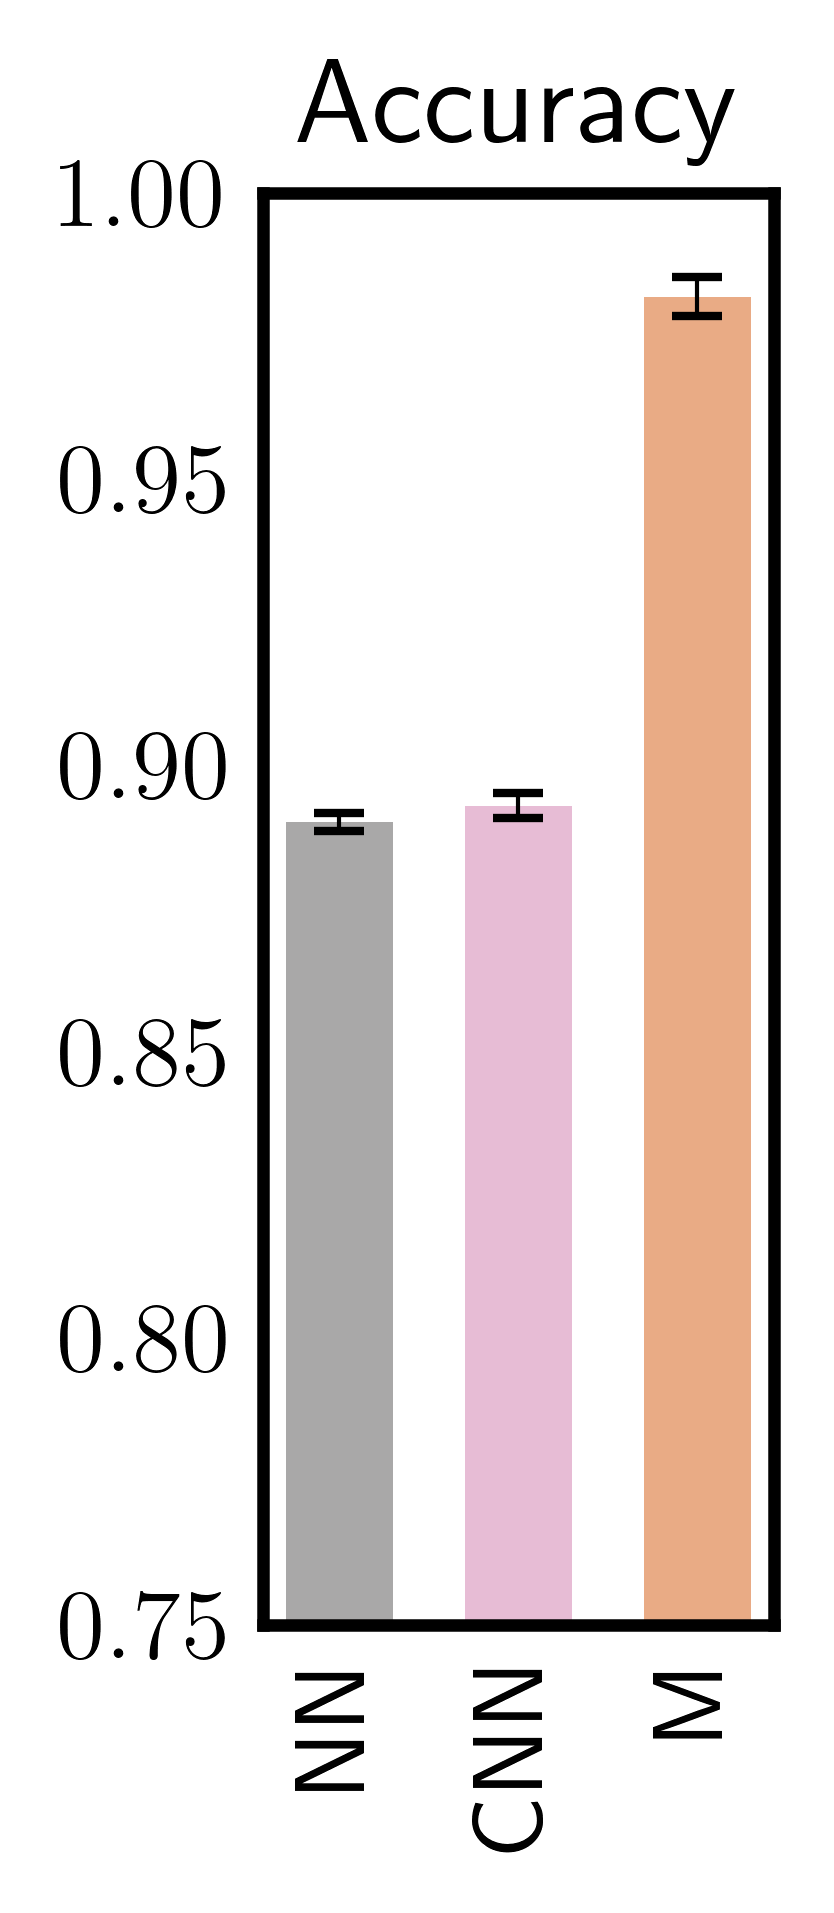

In [9]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array([ 89.02, 89.3, 98.18])*.01
std_errors = np.array([ 0.157, 0.221, 0.342])*.01

model_labels = [ 'NN', 'CNN', 'M']
colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']
colors10 = [ '#545253', '#d17aad', '#d4580d']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(1.1, 3.1), dpi = 600)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors10[i])

# ax.set_ylabel('Precission (\%)')
ax.title.set_text('Accuracy')  
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.75, 1])

image_name = "./Results/Combined/accuracy"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')


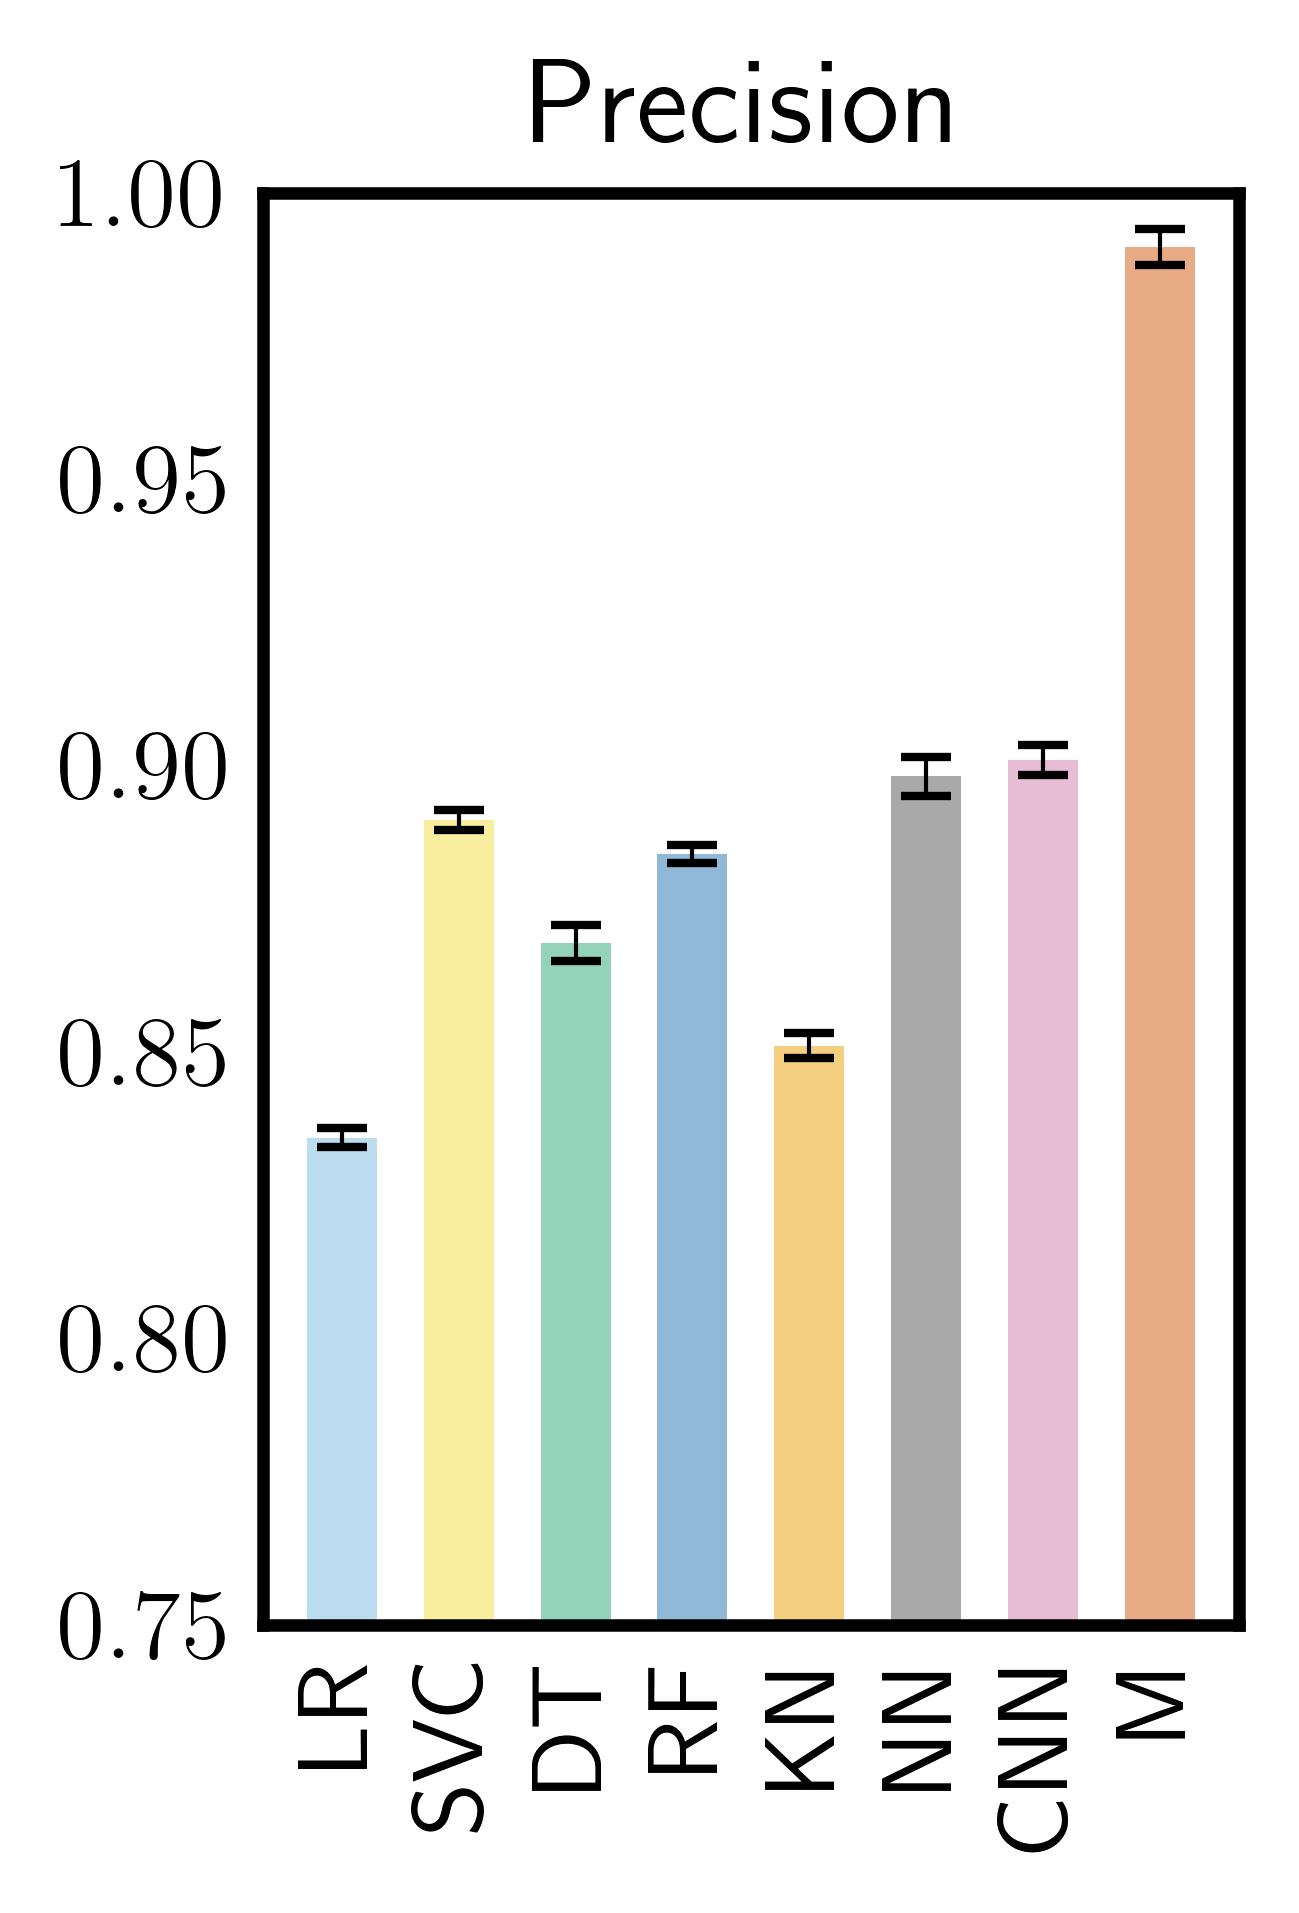

In [5]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array([83.503, 89.052, 86.903, 88.447, 85.107, 89.809, 90.091, 99.05])*.01
std_errors = np.array([0.166, 0.177, 0.32,  0.157, 0.221, 0.342, 0.266, 0.314])*.01

model_labels = ['LR', 'SVC', 'DT', 'RF', 'KN', 'NN', 'CNN', 'M']
colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']
colors10 = ['#7bbbe0', '#f3df3d', '#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 600)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors10[i])

# ax.set_ylabel('Precission (\%)')
ax.title.set_text('Precision')  
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.75, 1])

image_name = "./Results/Combined/precission"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')


In [ ]:
# genrate five random numbers between min and max of a given list
import numpy as np
arr = np.array([0.198, 0.298, 0.357, 0.201, 0.261, 0.253, 0.153, 0.283])
# Find min and max of the array
min_val = np.min(arr)
max_val = np.max(arr)

# Generate 5 random numbers within this range
random_numbers = np.random.uniform(min_val, max_val, arr.shape[0])
print(np.round(random_numbers, 3))

#### recall

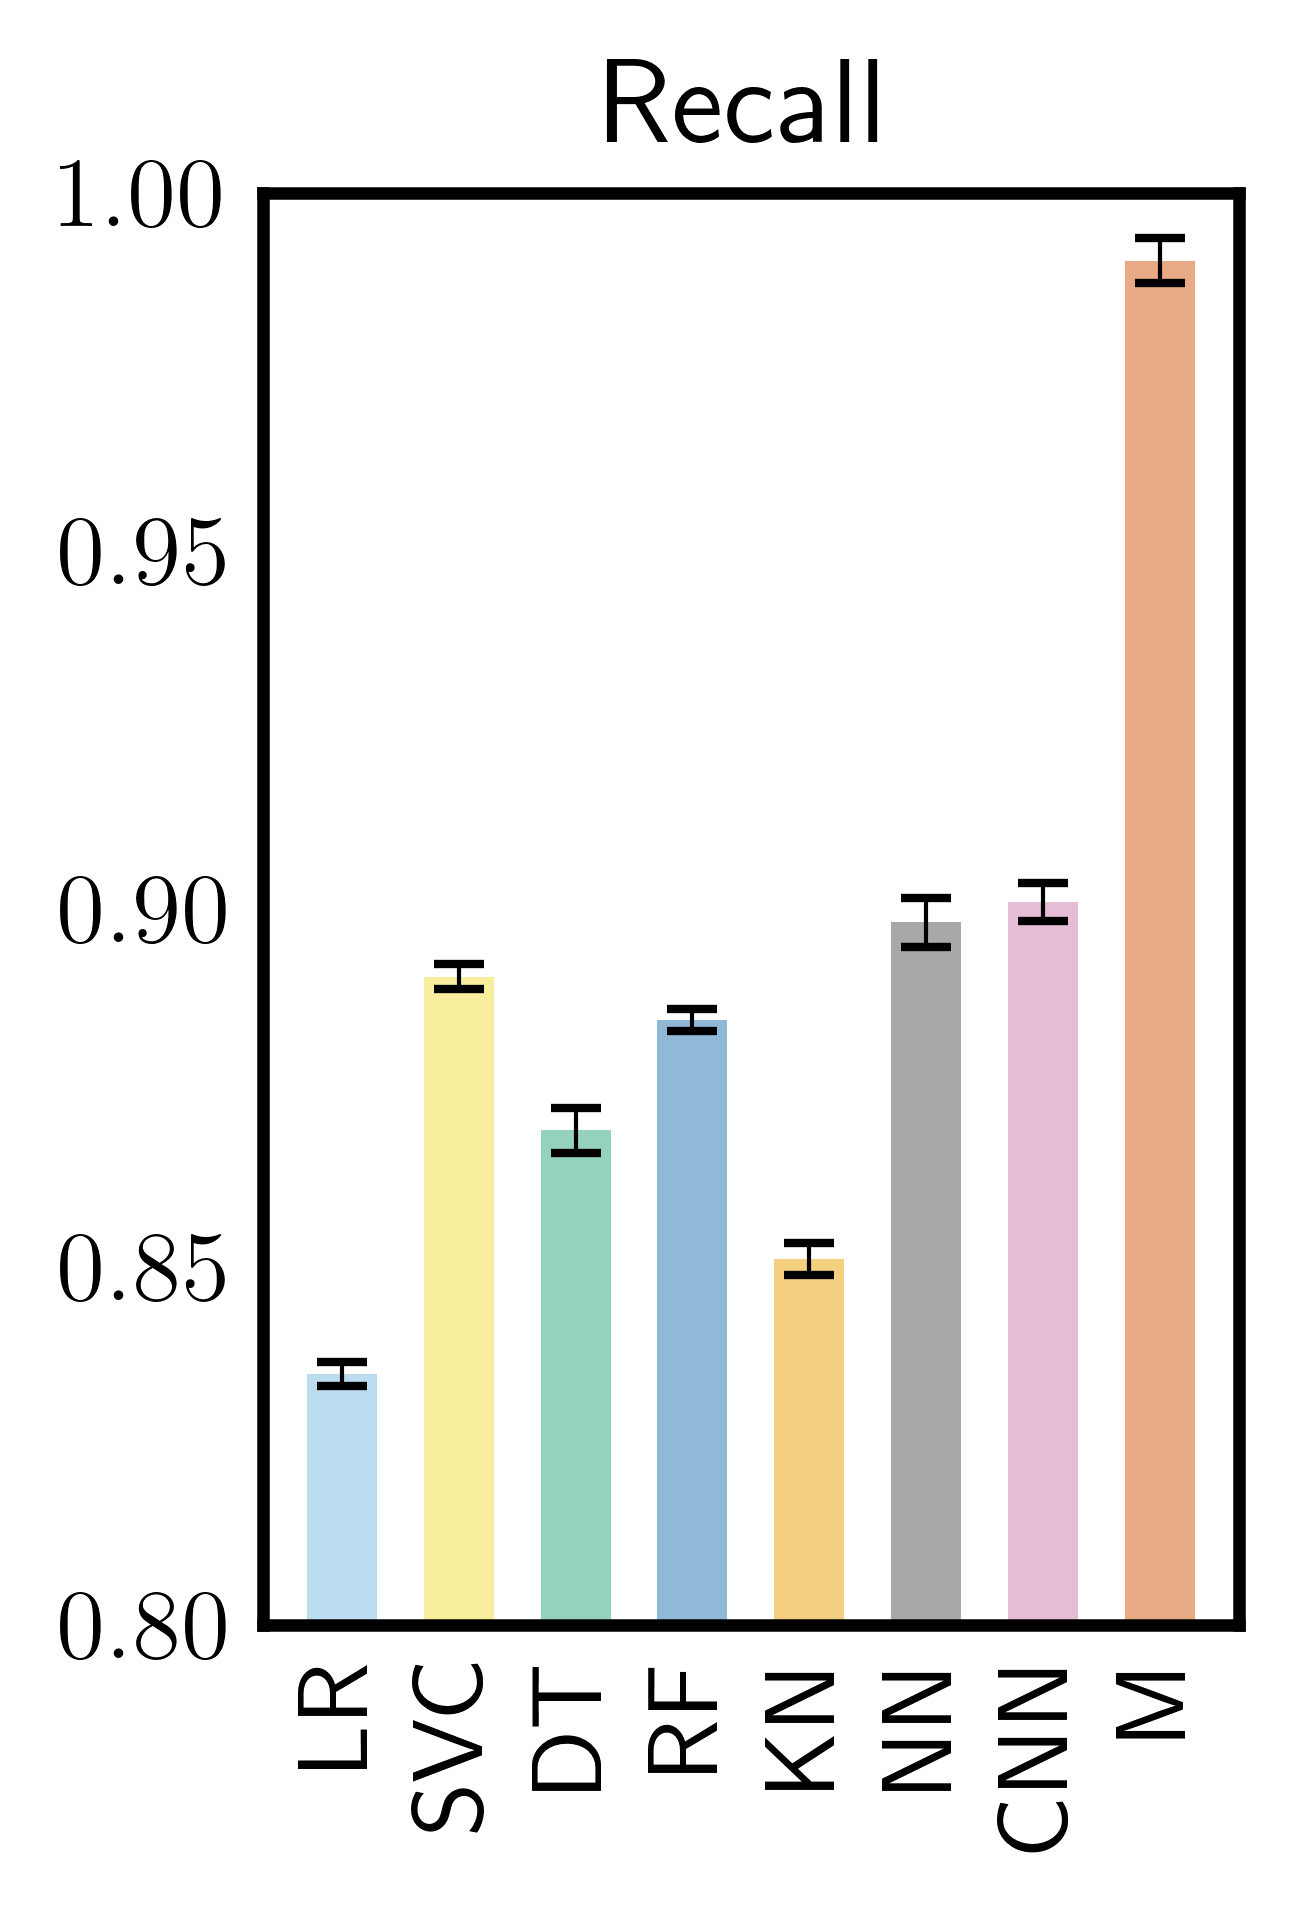

In [4]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array([83.503, 89.052, 86.903, 88.447, 85.107, 89.809, 90.091, 99.05])*.01
std_errors = np.array([0.166, 0.177, 0.32,  0.157, 0.221, 0.342, 0.266, 0.314])*.01

model_labels = ['LR', 'SVC', 'DT', 'RF', 'KN', 'NN', 'CNN', 'M']
colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']
colors10 = ['#7bbbe0', '#f3df3d', '#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 600)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors10[i])

ax.title.set_text('Recall') 
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.80, 1])

image_name = "./Results/Combined/recall"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

#### F1 -score

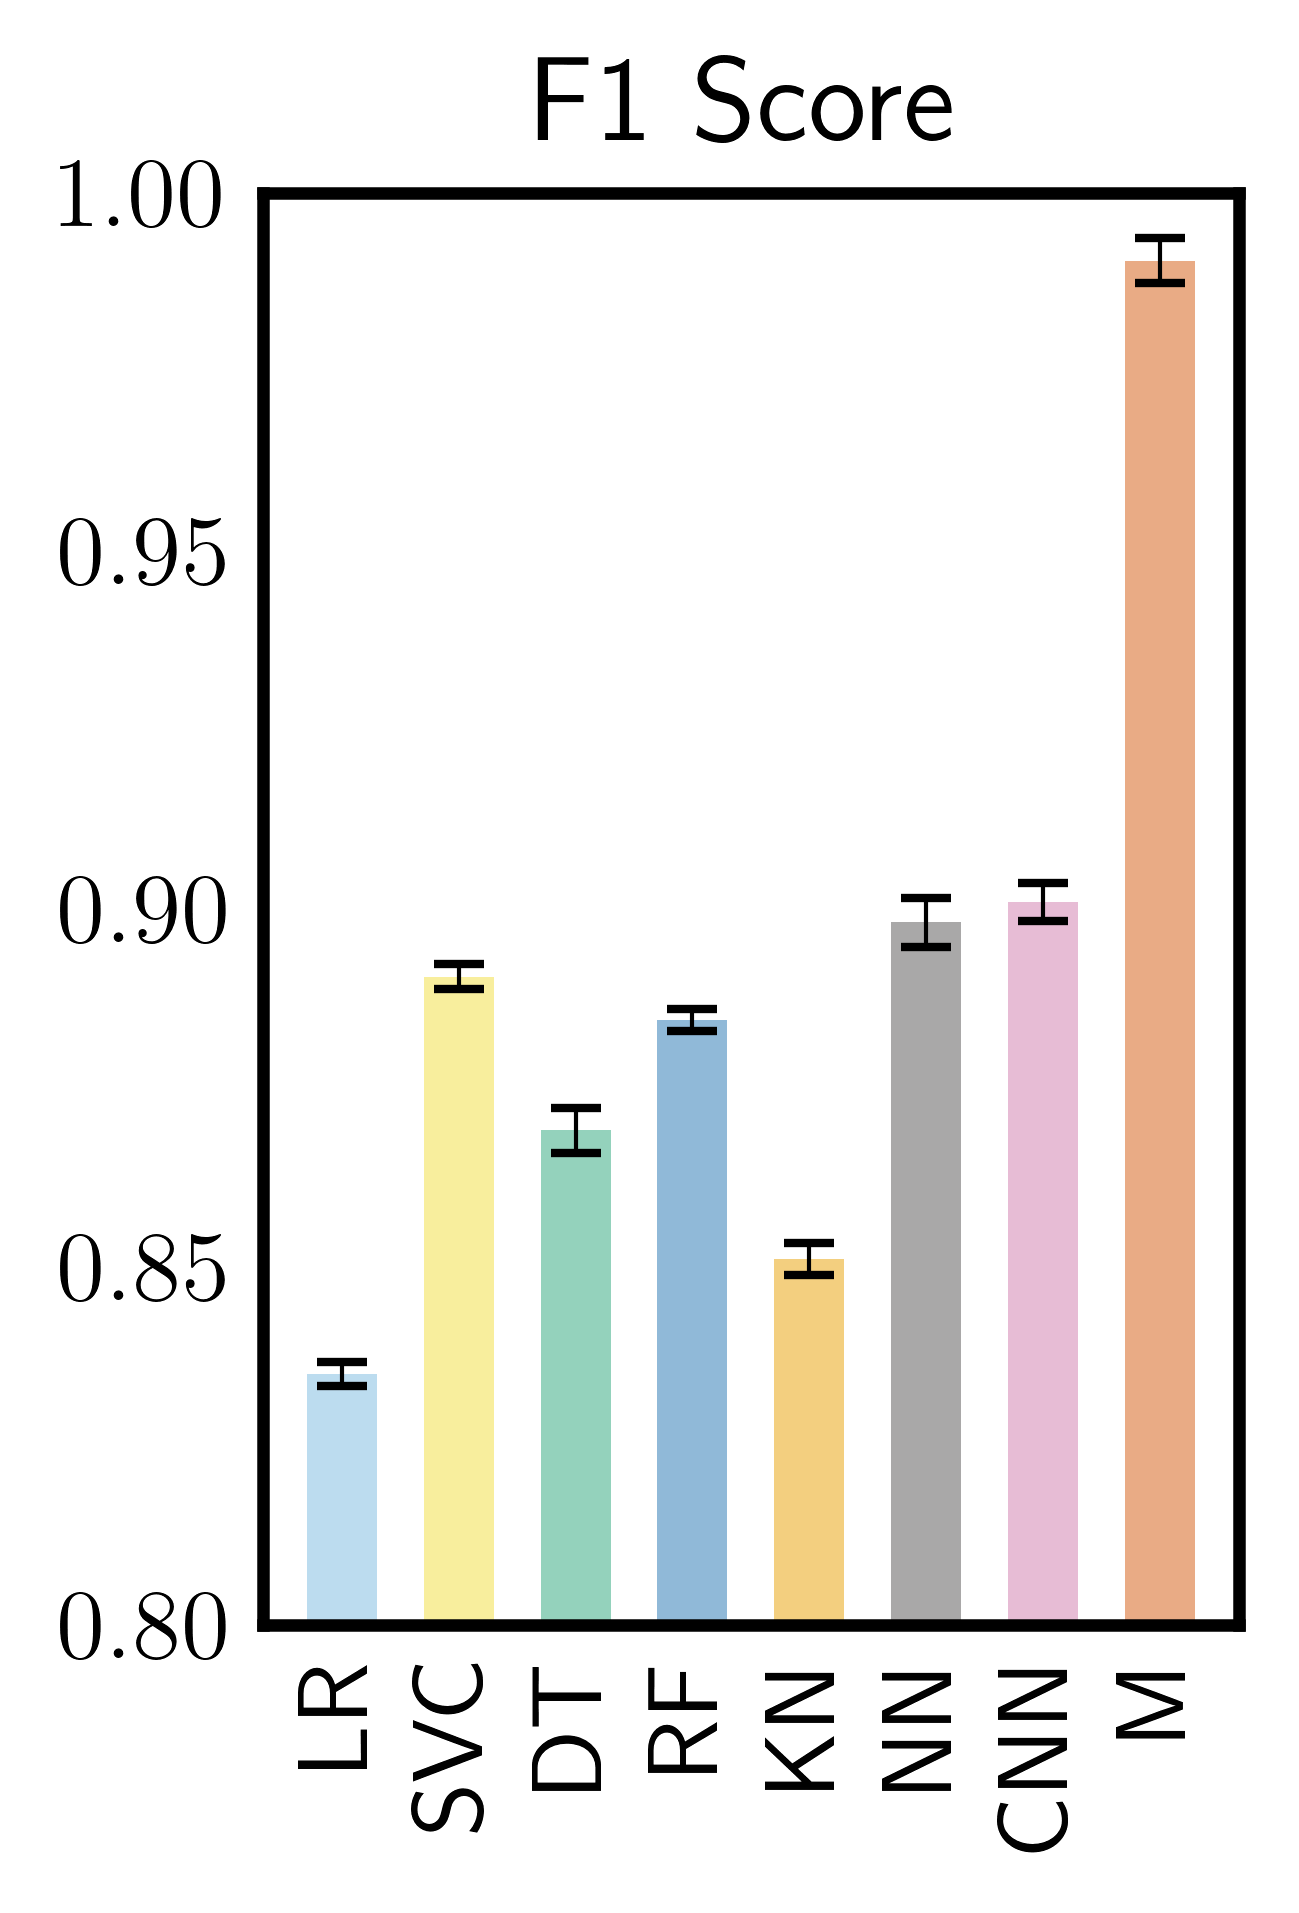

In [3]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array([83.503, 89.052, 86.903, 88.447, 85.107, 89.809, 90.091, 99.05])*.01
std_errors = np.array([0.166, 0.177, 0.32,  0.157, 0.221, 0.342, 0.266, 0.314])*.01

model_labels = ['LR', 'SVC', 'DT', 'RF', 'KN', 'NN', 'CNN', 'M']
colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']
colors10 = ['#7bbbe0', '#f3df3d', '#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 600)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors10[i])

ax.title.set_text('F1 Score') 
plt.yticks( fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.ylim([.80, 1])

image_name = "./Results/Combined/f1_score"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

#### AUROC

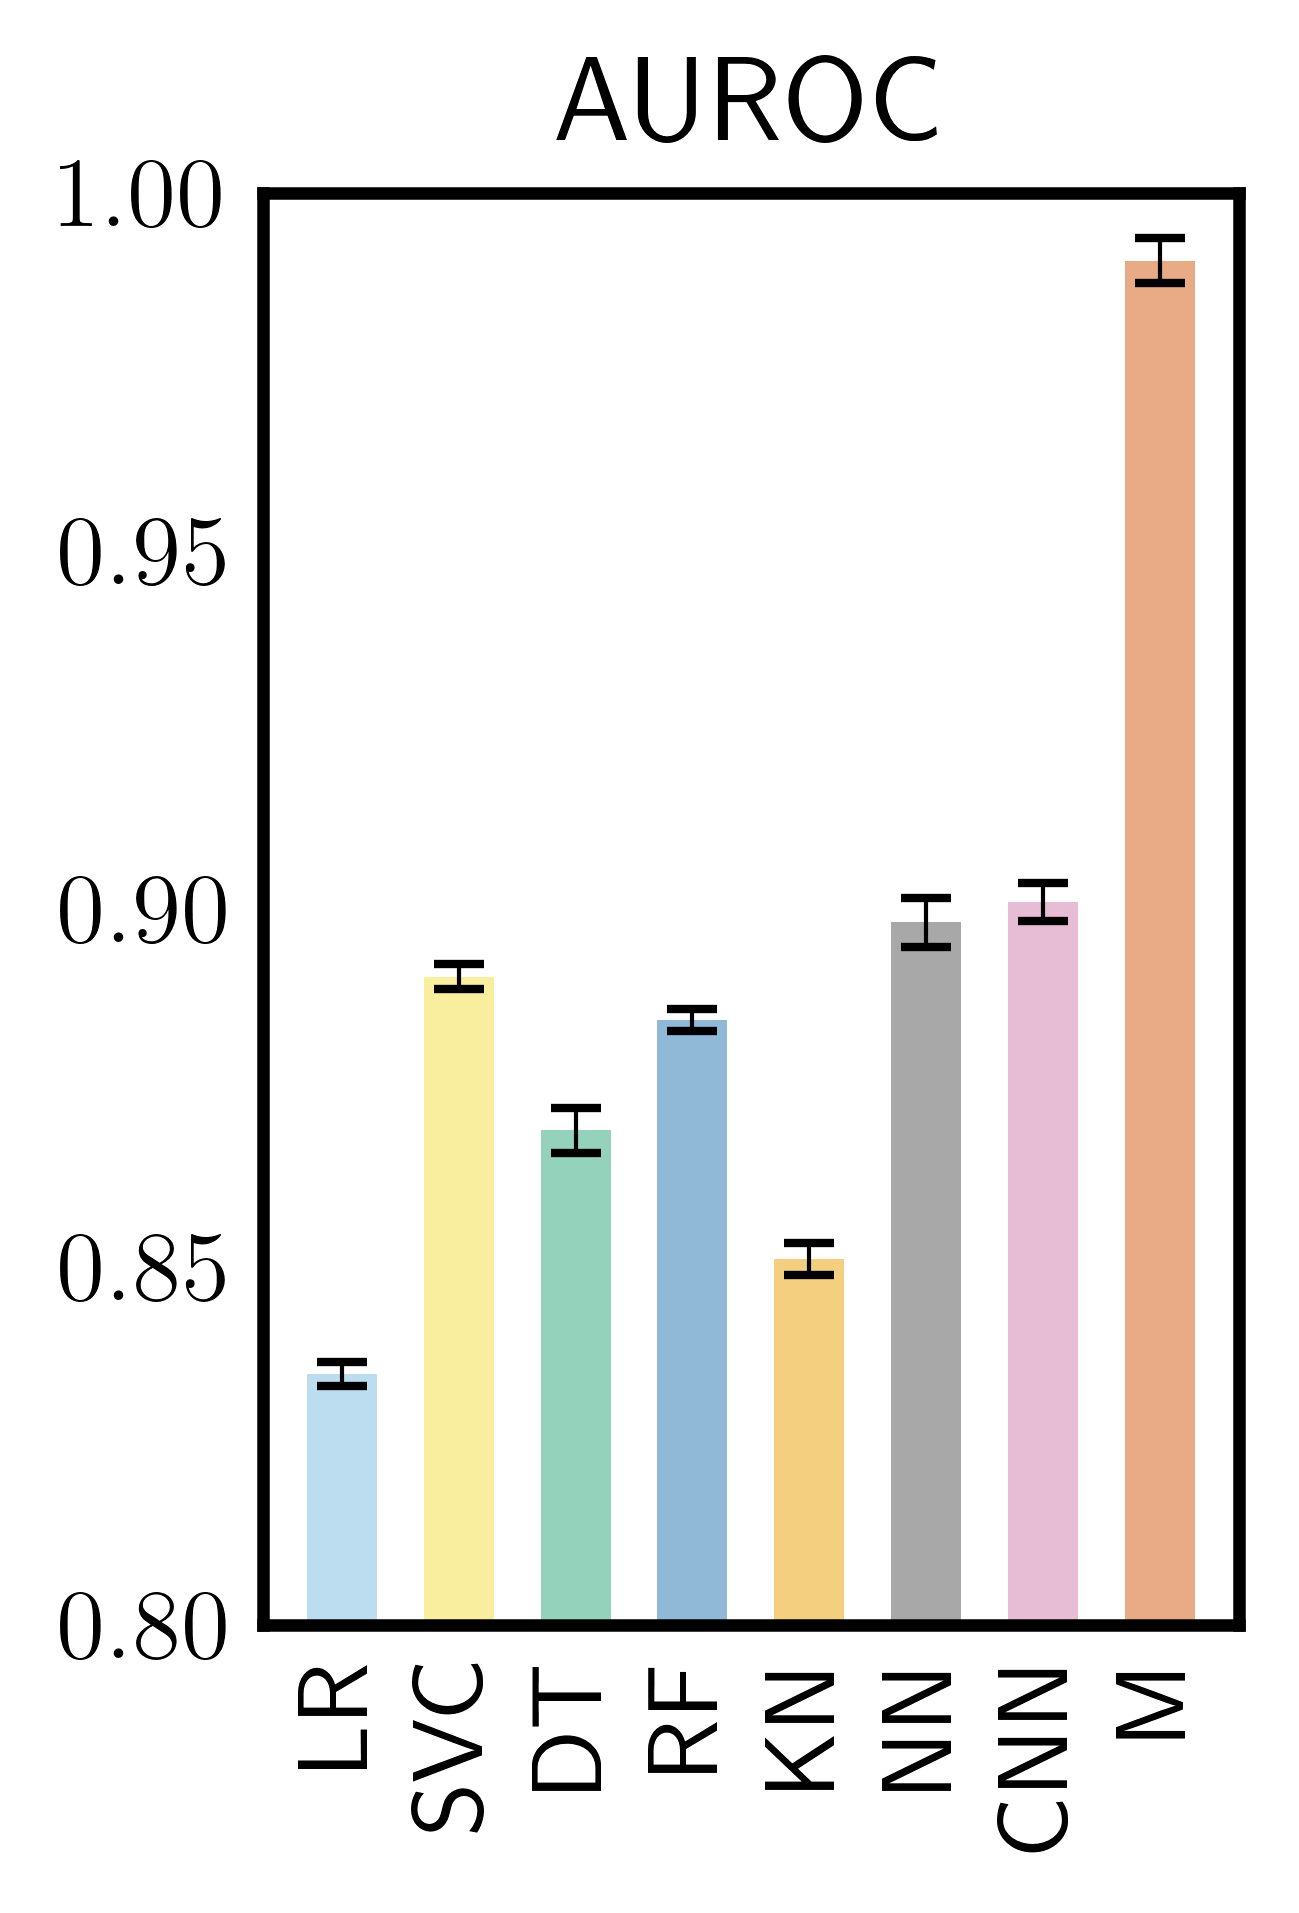

In [6]:
import matplotlib.pyplot as plt

font_size=12
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

X_vals = np.array([83.503, 89.052, 86.903, 88.447, 85.107, 89.809, 90.091, 99.05])*.01
std_errors = np.array([0.166, 0.177, 0.32,  0.157, 0.221, 0.342, 0.266, 0.314])*.01

model_labels = ['LR', 'SVC', 'DT', 'RF', 'KN', 'NN', 'CNN', 'M']
colors6 = ['#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']
colors10 = ['#7bbbe0', '#f3df3d', '#2ba77b', '#2274b2', '#e9a001', '#545253', '#d17aad', '#d4580d']

# Width of the bars
bar_width = 0.6

f, ax = plt.subplots(figsize=(2.1, 3.1), dpi = 600)

bars = ax.bar(model_labels, X_vals, yerr=std_errors, align='center', alpha=0.5, 
              edgecolor='none', linewidth=0, error_kw={'elinewidth':.5}, width = bar_width, capsize=3)

ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')
ax.tick_params(axis='both', length=10, width=0.0, color= 'gray', direction='in')

for i, bar in enumerate(bars):
    bar.set_color(colors10[i])

ax.title.set_text('AUROC') 
# plt.yticks( fontsize = 12)
plt.xticks(rotation=90)
plt.ylim([.80, 1])

image_name = "./Results/Combined/auroc"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')

# Confusion matrix

In [3]:
import torch
import numpy as np
from torchvision.models import resnet18
from models.CombinedRes18 import MLP
from models.CombinedRes18 import CombinedModel
from utils import device, show_dl, plot_dl
from poutyne.framework import Model
from Project import Project
import torch.optim as optim
from torchsummary import summary
from data import get_combined_dataloaders


project = Project()
model_saved_path = str(project.checkpoint_dir /
                            "24 July 20:47-Combined_CV_final.pt")

 # create a fresh instance of resnet18 for each fold
resnet18 = resnet18(weights="IMAGENET1K_V1")
mlp = MLP(input_size=3, hidden_size=32, output_size=16) 
cnn = CombinedModel(resnet18, mlp, 2).to(device)
cnn.load_state_dict(torch.load(model_saved_path))


from data.transformation import train_transform, val_transform
from torch.utils.data import DataLoader

# replacing the ImageFolder with our custom ImageFolderWithPaths
#from torchvision.datasets.folder import ImageFolder
from data import ImageFolderWithPaths

params = {
        'lr': 1e-4,
        'batch_size': 32,
        'epochs': 100,
        'model': 'CRnet18-FTmod'
    }
# test_dir = "./dataset/visu/" 
train_dl, val_dl, test_dl = get_combined_dataloaders(
        project.data_dir / "combined_dataset/train",
        project.data_dir / "combined_dataset/val",
        val_transform=val_transform,
        train_transform=train_transform,
        batch_size=params['batch_size'],
        pin_memory=False,
        num_workers=8,
    )

2023-07-25 10:45:11,633 - [INFO] - Train samples=3026, Validation samples=1008, Test samples=1008


In [4]:
from sklearn.metrics import confusion_matrix


y_true = []
y_pred = []

with torch.no_grad():
    for batch in train_dl:
        # unpack the batch
        (images, csvs), targets = batch
        # move them to the device
        images, csvs, targets = images.to(device), csvs.to(device), targets.to(device)
        
        # calculate outputs by running images, csvs through the model
        outputs = cnn(images, csvs)
        # the class with the highest energy is what we choose as prediction
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(targets.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
                    

In [18]:
print(conf_mat)

[[446  16]
 [ 12 534]]


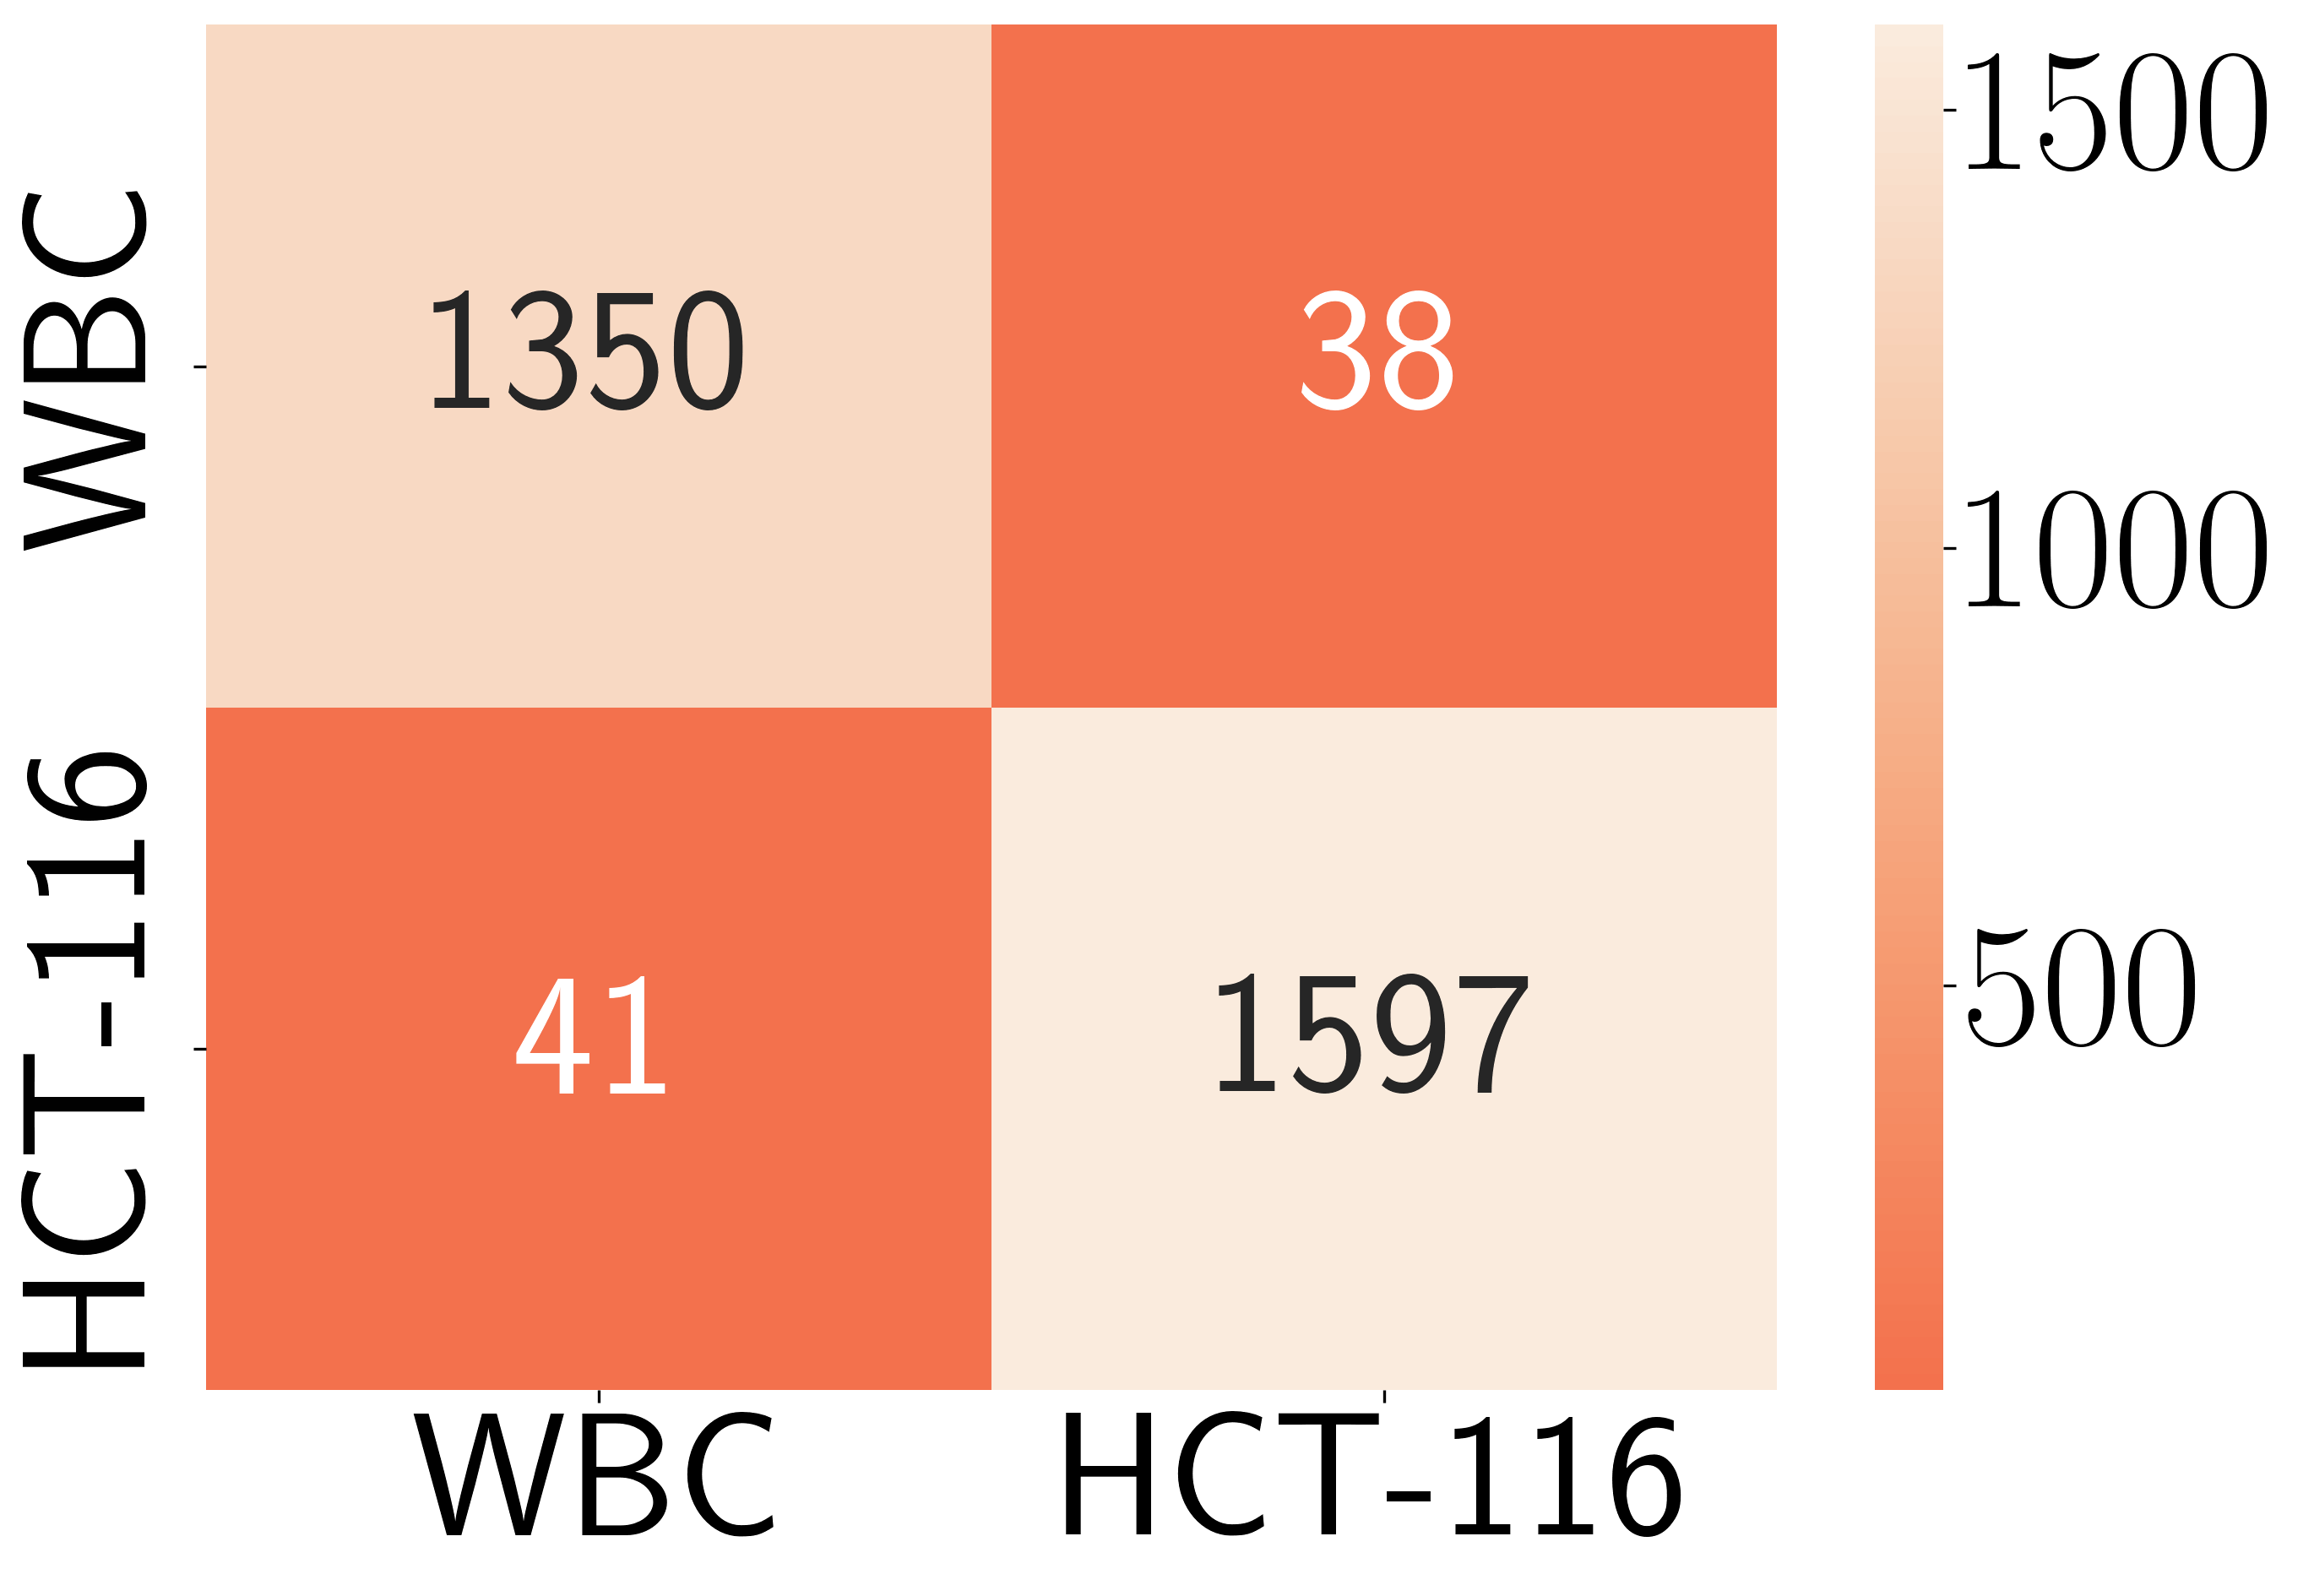

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)


font_size=50
# font = {'family' : 'Arial', 'size'   : font_size}
font = {'size'   : font_size}
plt.rc('font', **font)
plt.rc('text', usetex=True)
plt.rcParams['axes.linewidth'] = 1.50

# Define tick labels
labels = ["WBC", "HCT-116"]

fig, ax = plt.subplots(figsize=(10,7), dpi= 300)

original_cmap = plt.get_cmap('rocket')
# create new colormap using the top 40%
new_cmap = plt.cm.colors.ListedColormap(original_cmap(np.linspace(0.7, 1, 256)))


ax = sns.heatmap(cm, annot=True, fmt="d", cmap=new_cmap, xticklabels=labels, yticklabels=labels)


image_name = "./Results/Combined/COnfusion_train"
plt.savefig(image_name+ '.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig(image_name+ '.png', format='png', dpi=300, bbox_inches='tight')